In [ ]:
import boost_histogram as bh
import uproot
import os
import csv
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib as mpl
from scipy.optimize import curve_fit

def load_branch(filename, branches, run_type):
    with uproot.open(filename) as file:
        if run_type == "sim":
            tree = file["h10"]  
        else:
            tree = file["T"]     
        data = {br: tree[br].array(library="np") for br in branches}
    return pd.DataFrame(data)


def data_cuts(df):
    mask = (
        (df["H.gtr.dp"] > -8) & (df["H.gtr.dp"] < 8) &
        (df["P.gtr.dp"] > 0) & (df["P.gtr.dp"] < 2) &
        (df["P.cal.etottracknorm"] > 0.8) & (df["H.cal.etottracknorm"] < 0.7)
    )
    return df[mask]

def sim_cuts(df):
    """Apply physics cuts to DataFrame for SIMULATION."""
    mask = (
        (df["hsdelta"] > -8) & (df["hsdelta"] < 8) &
        (df["ssdelta"] > 0) & (df["ssdelta"] < 2)
    )
    return df[mask]

def fill_histogram_data(data, weights, bins, range, sf_sum):
    # define bin edges
    edges = np.linspace(range[0], range[1], bins + 1)
    sum_counts = np.zeros(bins)
    sum_variances = np.zeros(bins)

    for run_data, run_weights in zip(data, weights):
        hist = bh.Histogram(bh.axis.Variable(edges), storage=bh.storage.Weight())
        hist.fill(run_data, weight=run_weights)
        view = hist.view()
        sum_counts += view['value']
        sum_variances += view['variance']

    bin_centers = 0.5*(edges[:-1] + edges[1:])
    counts = sum_counts / sf_sum
    errors = np.sqrt(sum_variances) / np.abs(sf_sum)

    return bin_centers, counts, errors

def fill_histogram_sim(data, weights, bins, range, sf_sum):
    """Fill histogram with raw counts and normalize by sf_sum.
    Returns histogram, counts, and errors."""

    hist = bh.Histogram(bh.axis.Regular(bins, range[0],range[1]), storage=bh.storage.Weight())
    hist.fill(data, weight=weights)
    hist_view = hist.view()
    counts = hist_view['value']
    counts_norm = counts / sf_sum
    variances = hist_view['variance']
    errors = np.sqrt(variances) / np.abs(sf_sum)
    bin_centers = hist.axes[0].centers

    return bin_centers, counts_norm, errors

def process_runs(runs_df, R, normfac, var_to_plot, run_type):
    """Load all runs of a given type, apply cuts, return concatenated variable & weights."""
    subset = runs_df[runs_df["run_type"] == run_type]
    all_data = []
    all_weights = []

    if run_type in ["data", "dummy"]:
        sf_sum = 0
        branches = [
            "H.gtr.dp", "H.cal.etottracknorm", "H.cer.npeSum",
            "P.gtr.dp", "P.cal.etottracknorm", "P.kin.primary.W",
            "H.kin.secondary.emiss", "H.kin.secondary.pmiss_x", "H.kin.secondary.pmiss_y", "H.kin.secondary.pmiss_z"
        
        ]
        for _, row in subset.iterrows():
            df = load_branch(row.filename, branches, row.run_type)
            df_cut = data_cuts(df).copy()
            expr = var_to_plot[0]  
            # Include derived variables 
            df_cut["custom_var"] = df_cut.apply(lambda row: eval(expr, {"np": np, "row": row}),axis=1)
            colname = "custom_var"

             # raw yields → weight = 1
            all_data.append(df_cut[colname].to_numpy())
            all_weights.append(np.ones(len(df_cut)))

            # accumulate denominator
            eff = 1
            dead = 1
            denom = row.BCM2_Q * eff * dead
            if denom > 0:
                sf_sum +=  denom
        return all_data, np.concatenate(all_weights), sf_sum

    elif run_type == "sim":
        sf_sum = 1.0 # No scaling factor for sim
        branches = [
            "hsdelta", "ssdelta", "Weight", "hsytar", "Em_recon", "W_recon", "Pmx_recon", "Pmy_recon", "Pmz_recon"
        ]
        for _, row in subset.iterrows():
            df = load_branch(row.filename, branches, row.run_type)
            df_cut = sim_cuts(df).copy()
            # Normalize sim weights
            # w = df_cut["Weight"].to_numpy() * normfac / len(df_cut)
            w = df_cut["Weight"].to_numpy() * normfac / 1000000  # Normalize to 1M events instead of actual number of events
            # Evaluate derived variable for simulation
            expr = var_to_plot[1]
            df_cut["custom_var"] = df_cut.apply(lambda r: eval(expr, {"np": np, "row": r}),axis=1)
            all_data.append(df_cut["custom_var"].to_numpy())
            all_weights.append(w)      
        return np.concatenate(all_data), np.concatenate(all_weights), sf_sum
    

def make_histograms_cryo(runs_df, R, normfac, var_to_plot, bins, range):

    # Process all runs
    data_vals, data_weights, data_sf = process_runs(runs_df, R, normfac, var_to_plot, "data")
    dummy_vals, dummy_weights, dummy_sf = process_runs(runs_df, R, normfac, var_to_plot, "dummy")
    # random_vals, random_weights, random_sf = process_random(runs_df, R, normfac, var_to_plot, "data")
    sim_vals, sim_weights, sim_sf = process_runs(runs_df, R, normfac, var_to_plot, "sim")

    # def fill_histogram(data, weights, bins, range, sf_sum)

    # Fill histograms
    centers_data, counts_data, errors_data = fill_histogram_data(data_vals, data_weights, bins, range, data_sf)
    # centers_random, counts_random, errors_random = fill_histogram_data(random_vals, (1/4) * random_weights, bins, range, random_sf)
    centers_sim, counts_sim, errors_sim = fill_histogram_sim(sim_vals, sim_weights, bins, range, sim_sf)

    # Dummy target histograms

    # dummy_random_vals, dummy_random_weights, dummy_random_sf = process_random(runs_df, R, normfac, var_to_plot, "dummy")
    centers_dummy_tot, counts_dummy_tot, errors_dummy_tot = fill_histogram_data(dummy_vals, R * dummy_weights, bins, range, dummy_sf)
    # centers_dummy_random, counts_dummy_random, errors_dummy_random = fill_histogram_data(dummy_random_vals, (1/4) * R * dummy_random_weights, bins, range, dummy_random_sf)

    centers_dummy = centers_dummy_tot
    counts_dummy = counts_dummy_tot
    errors_dummy = np.sqrt(errors_dummy_tot**2)

     # Subtracted histogram

    centers_sub = centers_data
    # For cryotargets:
    counts_sub = counts_data - counts_dummy 
    errors_sub = np.sqrt(errors_data**2 + errors_dummy**2)


    yield_sim = float(np.sum(counts_sim))
    # yield_random = float(np.sum(counts_random))
    yield_dummy = float(np.sum(counts_dummy))
    yield_sub = float(np.sum(counts_sub))
    yield_data = float(np.sum(counts_data))

    # yield_err_random = np.sqrt(np.sum(errors_random**2))
    yield_err_sim = np.sqrt(np.sum(errors_sim**2))
    yield_err_sub = np.sqrt(np.sum(errors_sub**2))
    yield_err_dummy = np.sqrt(np.sum(errors_dummy**2))
    yield_err_data = np.sqrt(np.sum(errors_data**2))


    return {
        "centers_data": centers_data,
        "counts_data": counts_data,
        "errors_data": errors_data,
        "centers_dummy": centers_dummy,
        "counts_dummy": counts_dummy,
        "errors_dummy": errors_dummy,
        "centers_sim": centers_sim,
        "counts_sim": counts_sim,
        "errors_sim": errors_sim,
        "centers_sub": centers_sub,
        "counts_sub": counts_sub,
        "errors_sub": errors_sub,
        # "centers_random": centers_random,
        # "counts_random": counts_random,
        # "errors_random": errors_random,
        "yield_sim": yield_sim,
        "yield_err_sim": yield_err_sim,
        # "yield_random": yield_random,
        "yield_dummy": yield_dummy,
        # "yield_err_random": yield_err_random,
        "yield_err_dummy": yield_err_dummy,
        "yield_data": yield_data,
        "yield_err_data": yield_err_data,
        "yield_sub": yield_sub,
        "yield_err_sub": yield_err_sub
    }

def plot_histogram_cryo(config, xlabel, title="", csv_path=None):
    histo = make_histograms_cryo(**config)
    target_name = os.path.splitext(os.path.basename(csv_path))[0]

    # print(f"Data yield:    {histo['yield_data']:.2f} ± {histo['yield_err_data']:.2f}")
    # print(f"Sim yield:     {histo['yield_sim']:.2f} ± {histo['yield_err_sim']:.2f}")
    # print(f"Dummy yield:     {histo['yield_dummy']:.2f} ± {histo['yield_err_dummy']:.2f}")
    # # print(f"Random yield:  {histo['yield_random']:.2f} ± {histo['yield_err_random']:.2f}")
    # print(f"Sub yield:     {histo['yield_sub']:.2f} ± {histo['yield_err_sub']:.2f}")
    # print(f"Ratio (Data/Sim): {histo['yield_sub']/histo['yield_sim']:.3f}")


    fig, ax = plt.subplots(figsize=(15, 7))

    colors = plt.cm.tab10.colors

    # Histograms plots
    # plt.errorbar(histo["centers_data"], histo["counts_data"], yerr=np.abs(histo["errors_data"]),
    #              fmt='o', color=colors[0], label=f'{target_name} data', capsize=4, elinewidth=2, markeredgewidth=2)
    ax.errorbar(histo["centers_sim"], histo["counts_sim"], yerr=np.abs(histo["errors_sim"]),
                 fmt='s', color=colors[0], label='SIMC', capsize=0.5, elinewidth=1, markeredgewidth=1)
    # ax.errorbar(histo["centers_random"], histo["counts_random"], yerr=np.abs(histo["errors_random"]),
                #  fmt='o', color=colors[2], label="Random coincidences", capsize=4, elinewidth=2, markeredgewidth=2)
    # ax.errorbar(histo["centers_dummy"], histo["counts_dummy"], yerr=np.abs(histo["errors_dummy"]),
    #              fmt='o', color=colors[6], label="Dummy data", capsize=4, elinewidth=2, markeredgewidth=2)
    ax.errorbar(histo["centers_sub"], histo["counts_sub"], yerr=np.abs(histo["errors_sub"]),
                 fmt='o', color=colors[1], label="Data", capsize=0.5, elinewidth=1, markeredgewidth=1)

    ax.set_ylabel("Normalized yield (counts/mC)", fontsize=14)
    ax.set_xlabel(rf"{xlabel} (GeV)", fontsize=14)
    # ax.set_ylim(0, max(histo["counts_data"]) * 1.2)
    ax.ticklabel_format(axis='y', style='sci', scilimits=(0, 0))
    ax.minorticks_on()
    for spine in ax.spines.values():
        spine.set_linewidth(3)
        spine.set_color('black')
    ax.tick_params(which='major', length=8, width=1, direction='in', bottom=True, top=True,
                    left=True, right=True, labelsize=14)
    ax.tick_params(which='minor', length=4, width=1, direction='in', bottom=True, top=True,
                    left=True, right=True)
    ax.set_title(title, fontsize=16)

    def gaussian(x, a, mu, sigma):
        return a * np.exp(-0.5 * ((x - mu) / sigma) ** 2)

    x = histo['centers_sub']
    y = histo['counts_sub']

    approx_mu = np.average(x, weights=y)
    approx_sigma = np.sqrt(np.average((x - approx_mu)**2, weights=y))

    fit_mask = (x > approx_mu - approx_sigma) & (x < approx_mu + approx_sigma)

    popt_data, pcov_data = curve_fit(
        gaussian,
        x[fit_mask],
        y[fit_mask],
        p0=[y.max(), approx_mu, approx_sigma]
    )
    popt_sim, pcov_sim = curve_fit(
        gaussian,
        histo['centers_sim'],
        histo['counts_sim'],
        p0=[histo['counts_sim'].max(), approx_mu, approx_sigma]
    )

    # Plot fitted curves

    A_data, mu_data, sigma_data = popt_data
    A_sim, mu_sim, sigma_sim = popt_sim

    # Data
    x_data_fit = np.linspace(mu_data - sigma_data, mu_data + sigma_data, 300)

    # Simulation
    x_sim_fit  = np.linspace(mu_sim - sigma_sim, mu_sim + sigma_sim, 300)


    ax.plot(x_data_fit, gaussian(x_data_fit, *popt_data), 'g-', linewidth=2, label='Data fit')
    ax.plot(x_sim_fit,  gaussian(x_sim_fit,  *popt_sim),  'k-', linewidth=2, label='Sim fit')

    ax.legend(fontsize=14)
    ax.grid(True, which="both", linestyle="--", linewidth=1, alpha=0.4)

    print("Data Gaussian fit mean: ", f"{mu_data:.5f}", " sigma: ", f"{sigma_data:.5f}")
    print("Sim  Gaussian fit mean: ", f"{mu_sim:.5f}", " sigma: ", f"{sigma_sim:.5f}")
    print("Difference in means: ", f"{mu_data - mu_sim:.5f}")

    plt.tight_layout()
    plt.show()




Data Gaussian fit mean:  0.95256  sigma:  0.03405
Sim  Gaussian fit mean:  0.94672  sigma:  0.02180
Difference in means:  0.00584


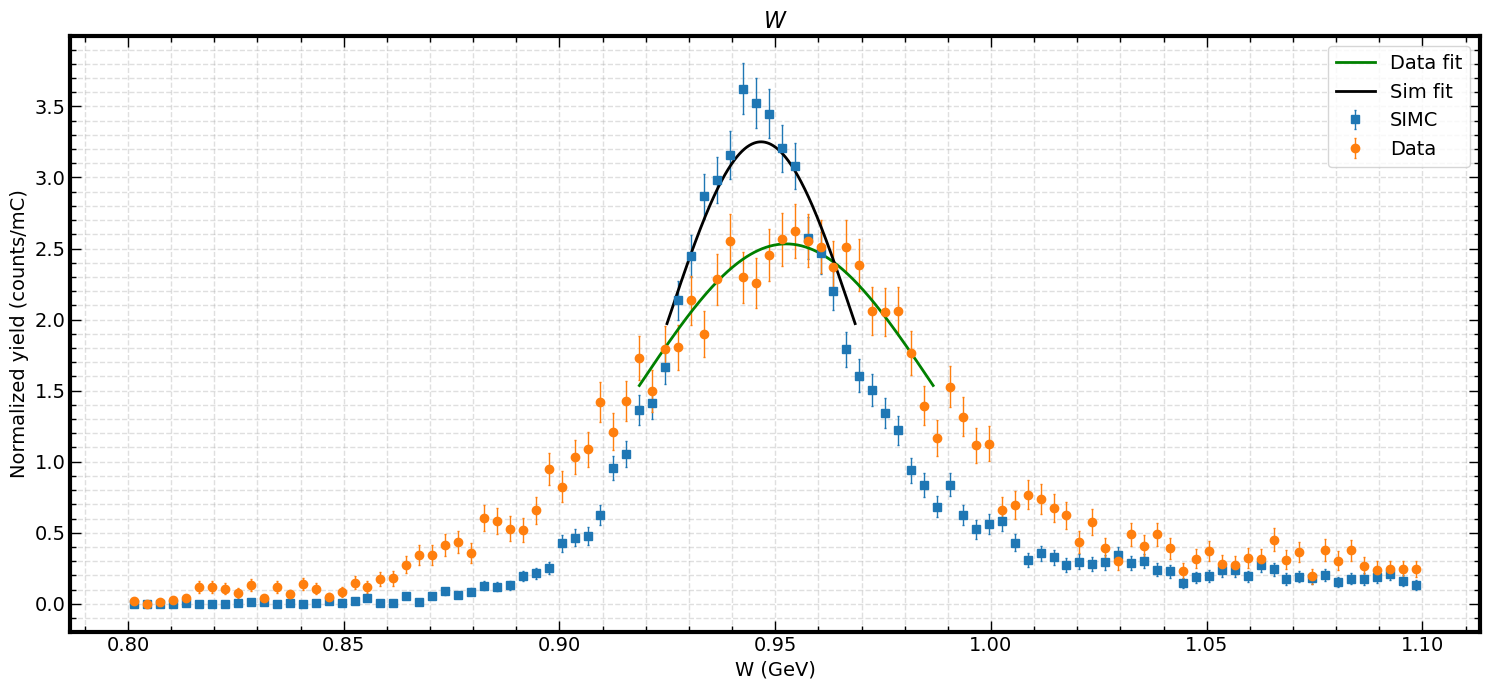

In [2]:
runs_df = pd.read_csv(f"P_6p72.csv")
csv_path = f"P_6p72.csv"
Al_thick = 0.095821  # g/cm2
dummy_thick = 0.3380  # g/cm2
R = Al_thick / dummy_thick
normfac = 0.125915E+11
# normfac = 0.9E+10

# Plot W
config_W = {
    'runs_df': runs_df,
    'R': R,
    'normfac': normfac,
    'var_to_plot': ["row['P.kin.primary.W']", "row['W_recon']"],
    'bins': 100,
    'range': (0.8, 1.1)
}

plot_histogram_cryo(config_W, xlabel="W", title=r"$W$" , csv_path=csv_path)


Data Gaussian fit mean:  -0.00836  sigma:  0.01099
Sim  Gaussian fit mean:  0.00620  sigma:  0.00390
Difference in means:  -0.01456


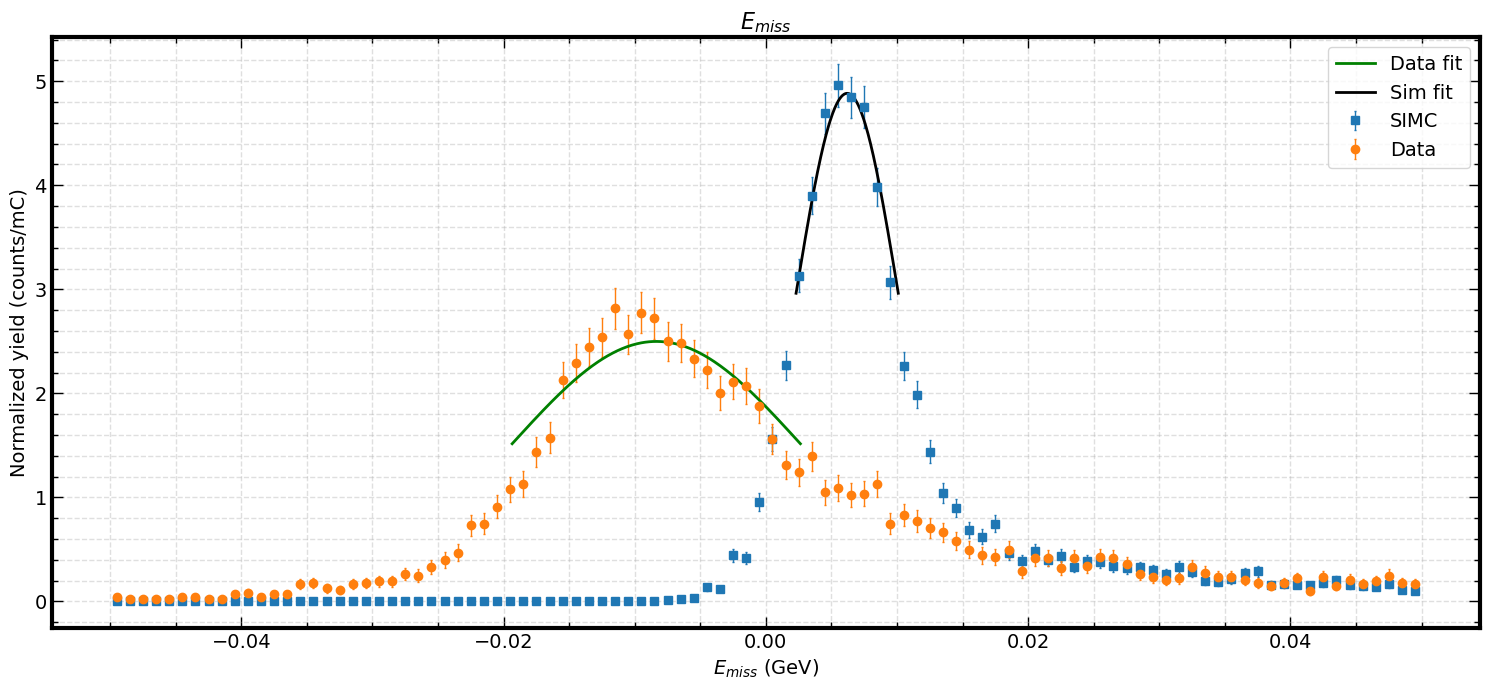

In [3]:
# Plot Emiss
config_Em = {
    'runs_df': runs_df,
    'R': R,
    'normfac': normfac,
    'var_to_plot': ["row['H.kin.secondary.emiss']", "row['Em_recon']"],
    'bins': 100,
    'range': (-0.05, 0.05)
}

plot_histogram_cryo(config_Em, xlabel=r"$E_{miss}$", title=r"$E_{miss}$", csv_path=csv_path)


Data Gaussian fit mean:  -0.00555  sigma:  0.01176
Sim  Gaussian fit mean:  -0.00327  sigma:  0.00772
Difference in means:  -0.00228


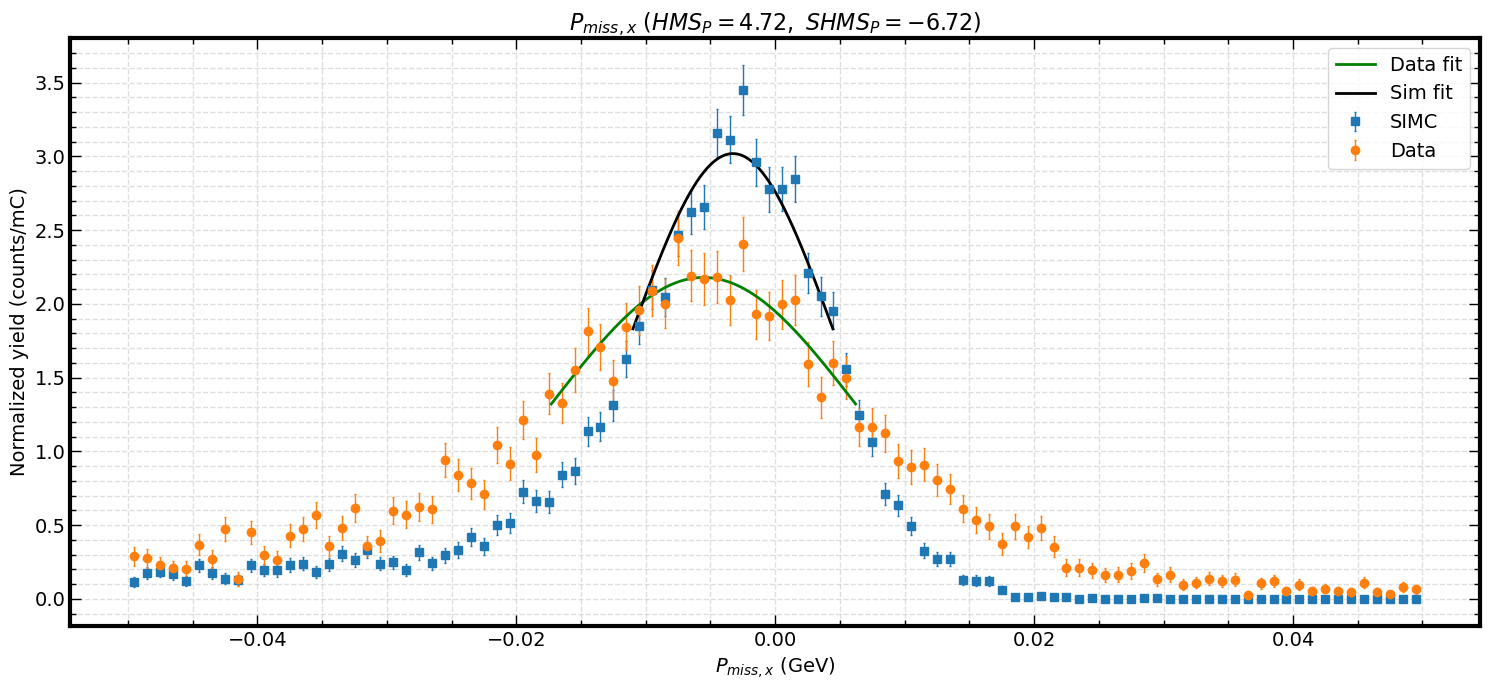

In [4]:
# Plot Pmiss_x
config_W = {
    'runs_df': runs_df,
    'R': R,
    'normfac': normfac,
    'var_to_plot': ["row['H.kin.secondary.pmiss_x']", "row['Pmx_recon']"],
    'bins': 100,
    'range': (-0.05, 0.05)
}

plot_histogram_cryo(config_W, xlabel=r"$P_{miss,x}$", title=r"$P_{miss,x}$ $(HMS_P = 4.72,$ $SHMS_P=-6.72)$", csv_path=csv_path)


Data Gaussian fit mean:  0.00788  sigma:  0.01113
Sim  Gaussian fit mean:  -0.00020  sigma:  0.00714
Difference in means:  0.00807


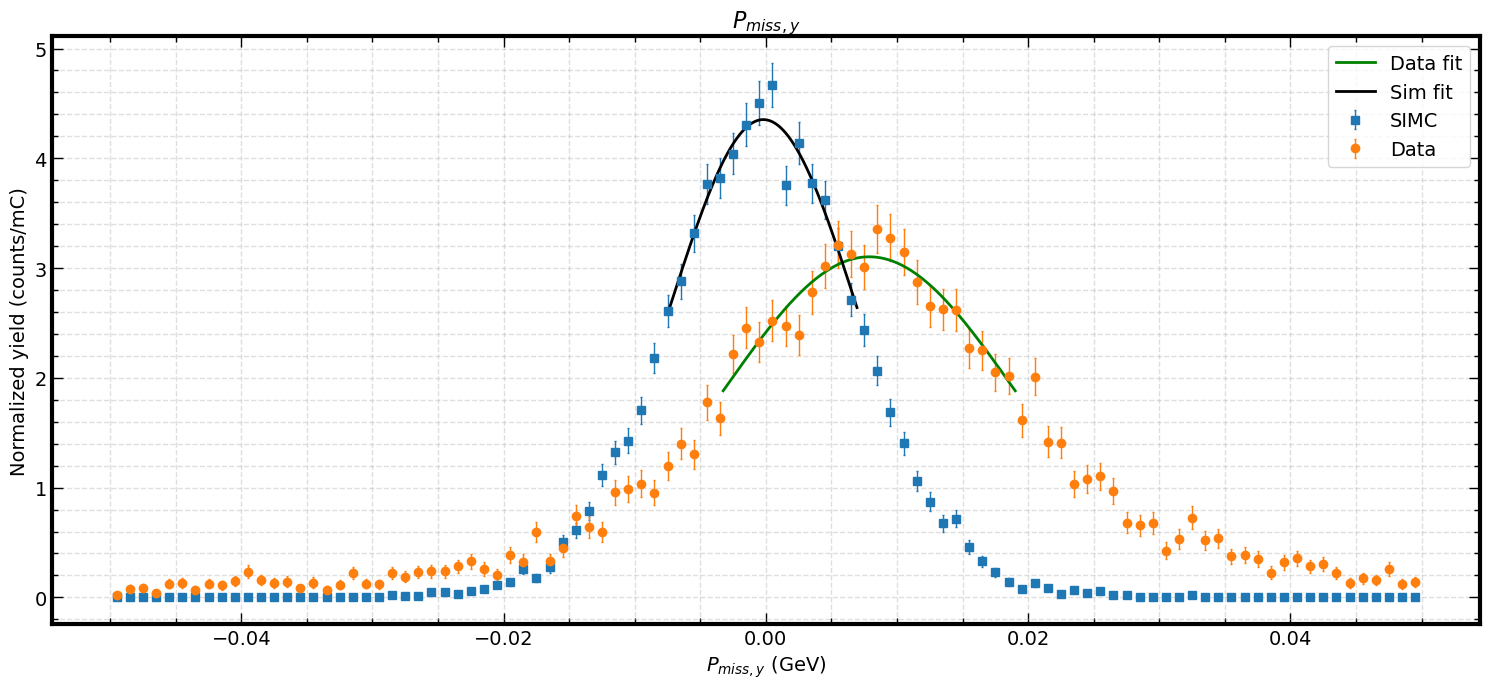

In [5]:
# Plot Pmiss_y
config_W = {
    'runs_df': runs_df,
    'R': R,
    'normfac': normfac,
    'var_to_plot': ["row['H.kin.secondary.pmiss_y']", "row['Pmy_recon']"],
    'bins': 100,
    'range': (-0.05, 0.05)
}

plot_histogram_cryo(config_W, xlabel=r"$P_{miss,y}$", title=r"$P_{miss,y}$", csv_path=csv_path)


Data Gaussian fit mean:  0.00945  sigma:  0.01166
Sim  Gaussian fit mean:  -0.00591  sigma:  0.00483
Difference in means:  0.01536


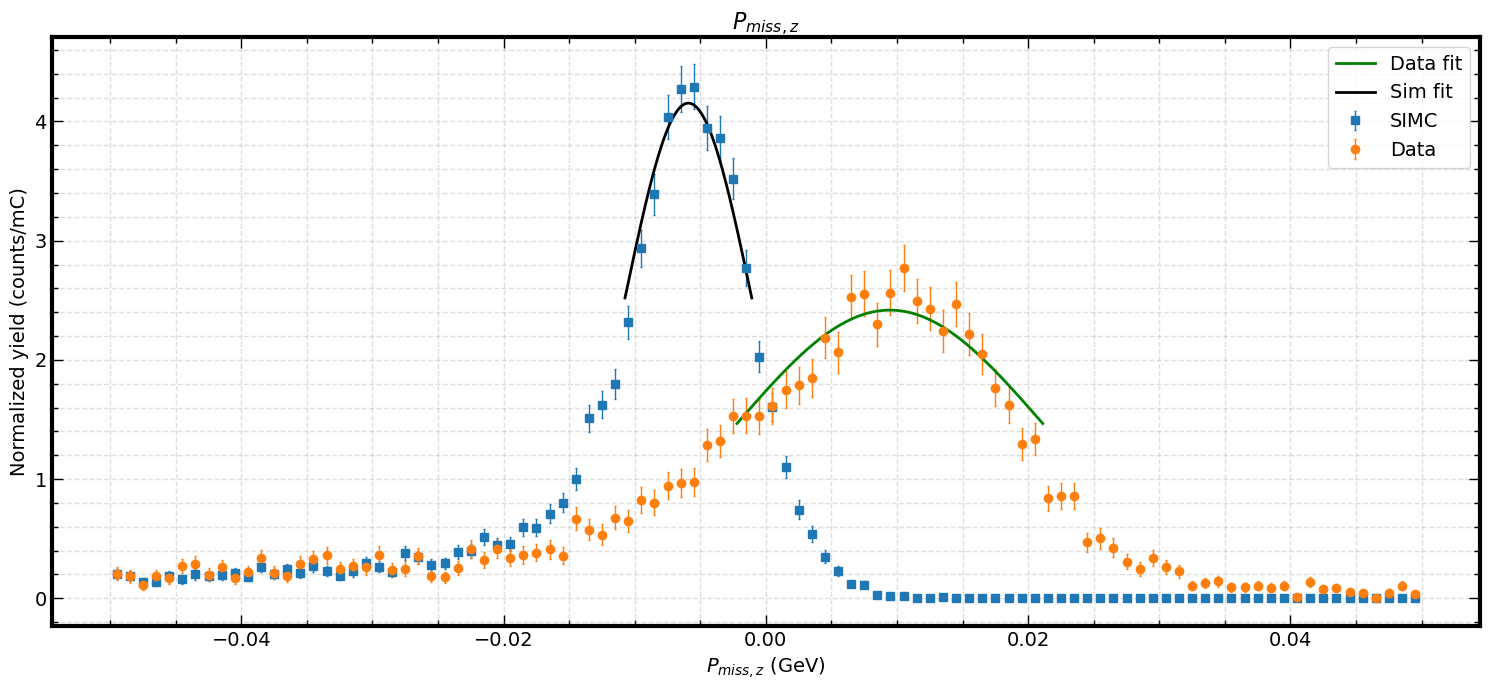

In [6]:
# Plot Pmiss_z
config_W = {
    'runs_df': runs_df,
    'R': R,
    'normfac': normfac,
    'var_to_plot': ["row['H.kin.secondary.pmiss_z']", "row['Pmz_recon']"],
    'bins': 100,
    'range': (-0.05, 0.05)
}

plot_histogram_cryo(config_W, xlabel=r"$P_{miss,z}$", title=r"$P_{miss,z}$", csv_path=csv_path)


In [7]:
import uproot
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as colors

def load_vars(filename):
    file = uproot.open(filename)
    tree = file["T"]

    emiss = tree["H.kin.secondary.emiss"].array(library="np")
    delta = tree["P.gtr.dp"].array(library="np")


    return emiss, delta

bins = [100, 100]
ranges = [[-7, 45], [-0.1, 0.1]]

emiss_1, delta_1 = load_vars("ROOTfiles/coin_replay_production_25476_-1.root")
emiss_2, delta_2 = load_vars("ROOTfiles/coin_replay_production_25477_-1.root")
emiss_3, delta_3 = load_vars("ROOTfiles/coin_replay_production_25478_-1.root")
emiss_4, delta_4 = load_vars("ROOTfiles/coin_replay_production_25479_-1.root")
emiss_5, delta_5 = load_vars("ROOTfiles/coin_replay_production_25480_-1.root")
emiss_6, delta_6 = load_vars("ROOTfiles/coin_replay_production_25481_-1.root")
emiss_7, delta_7 = load_vars("ROOTfiles/coin_replay_production_25482_-1.root")
emiss_8, delta_8 = load_vars("ROOTfiles/coin_replay_production_25483_-1.root")


fig, ax = plt.subplots(figsize=(12, 7))
ax.hist2d(delta_1, emiss_1, bins=bins, range=ranges, norm=colors.LogNorm(), cmap='turbo');
ax.hist2d(delta_2, emiss_2, bins=bins, range=ranges, norm=colors.LogNorm(), cmap='turbo');
ax.hist2d(delta_3, emiss_3, bins=bins, range=ranges, norm=colors.LogNorm(), cmap='turbo');
ax.hist2d(delta_4, emiss_4, bins=bins, range=ranges, norm=colors.LogNorm(), cmap='turbo');
ax.hist2d(delta_5, emiss_5, bins=bins, range=ranges, norm=colors.LogNorm(), cmap='turbo');
ax.hist2d(delta_6, emiss_6, bins=bins, range=ranges, norm=colors.LogNorm(), cmap='turbo');
ax.hist2d(delta_7, emiss_7, bins=bins, range=ranges, norm=colors.LogNorm(), cmap='turbo');
ax.hist2d(delta_8, emiss_8, bins=bins, range=ranges, norm=colors.LogNorm(), cmap='turbo');
ax.set_xlabel("SHMS dp (%)", fontsize=14)
ax.set_ylabel("Emiss (GeV)", fontsize=14)
ax.set_title(r"SHMS delta vs $E_{miss}$", fontsize=16)

KeyboardInterrupt: 

Text(0.5, 1.0, '$E_{miss} vs HMS delta$')

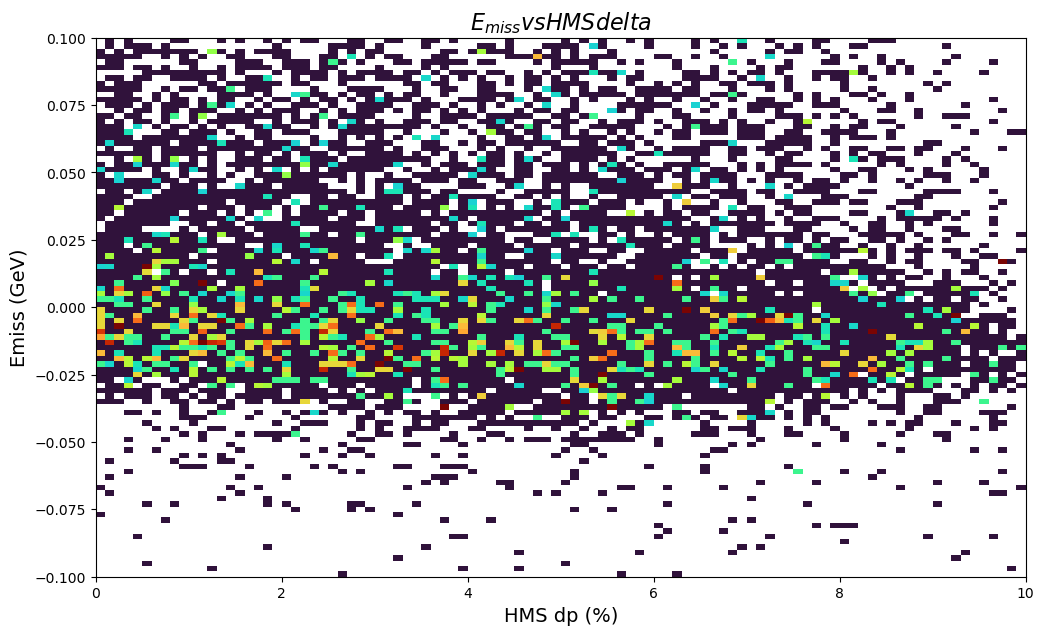

In [ ]:
import uproot
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.colors as colors

def load_vars(filename):
    file = uproot.open(filename)
    tree = file["T"]

    emiss = pd.DataFrame(tree["H.kin.secondary.emiss"].array(library="np"))
    delta_hms = pd.DataFrame(tree["H.gtr.dp"].array(library="np"))
    delta_shms = pd.DataFrame(tree["P.gtr.dp"].array(library="np"))



    return emiss, delta_hms
bins = [100, 100]
ranges = [[0,10], [-0.1, 0.1]]

emiss_1, delta_1 = load_vars("ROOTfiles/coin_replay_production_25476_-1.root")
emiss_2, delta_2 = load_vars("ROOTfiles/coin_replay_production_25477_-1.root")
emiss_3, delta_3 = load_vars("ROOTfiles/coin_replay_production_25478_-1.root")
emiss_4, delta_4 = load_vars("ROOTfiles/coin_replay_production_25479_-1.root")
emiss_5, delta_5 = load_vars("ROOTfiles/coin_replay_production_25480_-1.root")
emiss_6, delta_6 = load_vars("ROOTfiles/coin_replay_production_25481_-1.root")
emiss_7, delta_7 = load_vars("ROOTfiles/coin_replay_production_25482_-1.root")
emiss_8, delta_8 = load_vars("ROOTfiles/coin_replay_production_25483_-1.root")


fig, ax = plt.subplots(figsize=(12, 7))
ax.hist2d(delta_1.iloc[:,0], emiss_1.iloc[:,0], bins=bins, range=ranges, norm=colors.LogNorm(), cmap='turbo');
ax.hist2d(delta_2.iloc[:,0], emiss_2.iloc[:,0], bins=bins, range=ranges, norm=colors.LogNorm(), cmap='turbo');
ax.hist2d(delta_3.iloc[:,0], emiss_3.iloc[:,0], bins=bins, range=ranges, norm=colors.LogNorm(), cmap='turbo');
ax.hist2d(delta_4.iloc[:,0], emiss_4.iloc[:,0], bins=bins, range=ranges, norm=colors.LogNorm(), cmap='turbo');
ax.hist2d(delta_5.iloc[:,0], emiss_5.iloc[:,0], bins=bins, range=ranges, norm=colors.LogNorm(), cmap='turbo');
ax.hist2d(delta_6.iloc[:,0], emiss_6.iloc[:,0], bins=bins, range=ranges, norm=colors.LogNorm(), cmap='turbo');
ax.hist2d(delta_7.iloc[:,0], emiss_7.iloc[:,0], bins=bins, range=ranges, norm=colors.LogNorm(), cmap='turbo');
ax.hist2d(delta_8.iloc[:,0], emiss_8.iloc[:,0], bins=bins, range=ranges, norm=colors.LogNorm(), cmap='turbo');
ax.set_xlabel("HMS dp (%)", fontsize=14)
ax.set_ylabel("Emiss (GeV)", fontsize=14)
ax.set_title(r"$E_{miss} vs HMS delta$", fontsize=16)